#  Project: Customer Purchase Data Analysis

# Data Cleaning & Visualization Project

- Requirements:
-- Handle missing values
-- Handle outliers
-- Remove duplicates
-- Use Pandas + Matplotlib/Seaborn
-- Create dashboard/visual reports
-- Show insights

In [3]:
import pandas as pd

data = pd.read_csv("Data-Cleaning-Visualization/dataset/customer_sales_data.csv")

print(data.head())
print(data.info())
print(data.isnull().sum())

   Customer_ID  Age  Gender        City  Monthly_Spend  Orders  Rating
0          101   21    Male   Hyderabad         1200.0       5     4.2
1          102   22  Female  Vijayawada         1500.0       6     4.5
2          103   23    Male      Guntur            NaN       7     4.1
3          104   22  Female     Chennai         1800.0       8     4.7
4          105   24    Male   Bangalore         2200.0      10     4.8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer_ID    21 non-null     int64  
 1   Age            21 non-null     int64  
 2   Gender         21 non-null     object 
 3   City           21 non-null     object 
 4   Monthly_Spend  19 non-null     float64
 5   Orders         21 non-null     int64  
 6   Rating         20 non-null     float64
dtypes: float64(2), int64(3), object(2)
memory usage: 1.3+ KB
None
Customer_

# Workflow
## Load Dataset

In [4]:
import pandas as pd

dataset = pd.read_csv("Data-Cleaning-Visualization/dataset/customer_sales_data.csv")
print(dataset.head())

   Customer_ID  Age  Gender        City  Monthly_Spend  Orders  Rating
0          101   21    Male   Hyderabad         1200.0       5     4.2
1          102   22  Female  Vijayawada         1500.0       6     4.5
2          103   23    Male      Guntur            NaN       7     4.1
3          104   22  Female     Chennai         1800.0       8     4.7
4          105   24    Male   Bangalore         2200.0      10     4.8


# Handle Missing Values

In [5]:
dataset.fillna(dataset.mean(numeric_only=True), inplace=True)
dataset

,Customer_ID,Age,Gender,City,Monthly_Spend,Orders,Rating
0,101,21,Male,Hyderabad,1200.000000,5,4.200
1,102,22,Female,Vijayawada,1500.000000,6,4.500
2,103,23,Male,Guntur,4278.947368,7,4.100
3,104,22,Female,Chennai,1800.000000,8,4.700
4,105,24,Male,Bangalore,2200.000000,10,4.800
5,106,25,Female,Hyderabad,2500.000000,12,4.335
6,107,23,Male,Vijayawada,3000.000000,14,4.400
7,108,21,Female,Guntur,1100.000000,5,3.800
8,109,26,Male,Chennai,45000.000000,90,5.000
9,110,22,Female,Bangalore,1700.000000,8,4.000


# Remove Duplicates

In [6]:
dataset.drop_duplicates(inplace=True)
dataset

,Customer_ID,Age,Gender,City,Monthly_Spend,Orders,Rating
0,101,21,Male,Hyderabad,1200.000000,5,4.200
1,102,22,Female,Vijayawada,1500.000000,6,4.500
2,103,23,Male,Guntur,4278.947368,7,4.100
3,104,22,Female,Chennai,1800.000000,8,4.700
4,105,24,Male,Bangalore,2200.000000,10,4.800
5,106,25,Female,Hyderabad,2500.000000,12,4.335
6,107,23,Male,Vijayawada,3000.000000,14,4.400
7,108,21,Female,Guntur,1100.000000,5,3.800
8,109,26,Male,Chennai,45000.000000,90,5.000
9,110,22,Female,Bangalore,1700.000000,8,4.000


# Handle Outliers

In [7]:
outlier_columns = ['Age', 'Monthly_Spend', 'Orders', 'Rating']

Q1 = dataset[outlier_columns].quantile(0.25)
Q3 = dataset[outlier_columns].quantile(0.75)

IQR = Q3 - Q1

dataset = dataset[
    ~((dataset[outlier_columns] < (Q1 - 1.5 * IQR)) |
      (dataset[outlier_columns] > (Q3 + 1.5 * IQR))).any(axis=1)
]
print(dataset.dtypes)

Customer_ID        int64
Age                int64
Gender            object
City              object
Monthly_Spend    float64
Orders             int64
Rating           float64
dtype: object


# Visualization

#                               1. Dataset Overview

In [8]:
import pandas as pd

print(dataset.describe())
print(dataset.info())

       Customer_ID        Age  Monthly_Spend     Orders     Rating
count    17.000000  17.000000      17.000000  17.000000  17.000000
mean    110.941176  23.058824    2035.294118   8.941176   4.331471
std       6.128525   1.344925     562.295715   2.771971   0.297320
min     101.000000  21.000000    1100.000000   5.000000   3.800000
25%     106.000000  22.000000    1700.000000   7.000000   4.100000
50%     111.000000  23.000000    1900.000000   8.000000   4.335000
75%     116.000000  24.000000    2500.000000  11.000000   4.600000
max     120.000000  25.000000    3000.000000  14.000000   4.800000
<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, 0 to 19
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer_ID    17 non-null     int64  
 1   Age            17 non-null     int64  
 2   Gender         17 non-null     object 
 3   City           17 non-null     object 
 4   Monthly_Spend  17 non-null     

#                     2. Missing Values Heatmap

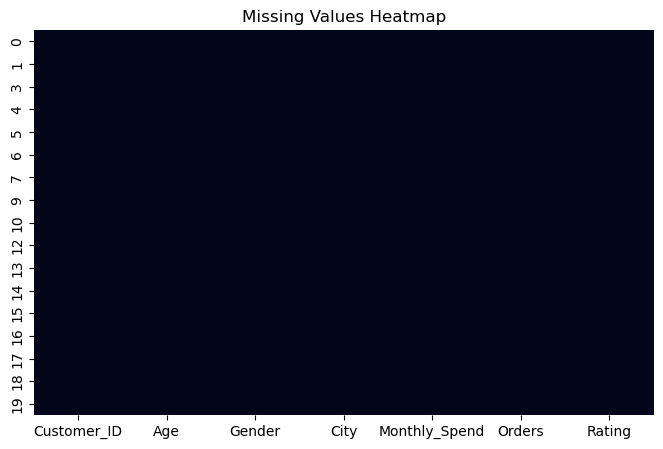

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(dataset.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# 3. Age Distribution (Histogram)

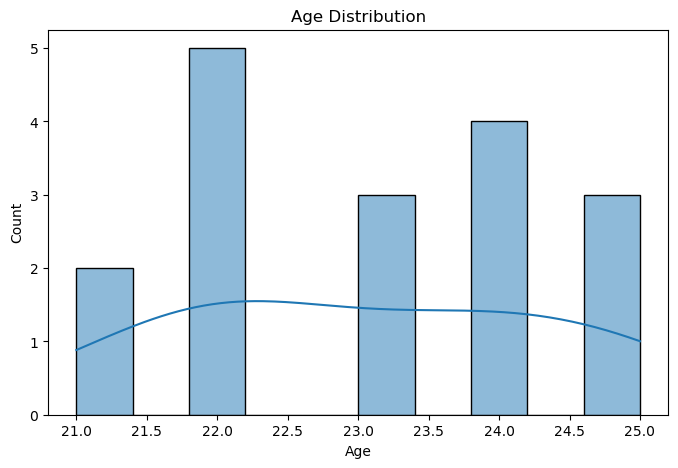

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(dataset['Age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.show()

# 4. Monthly Spend Distribution

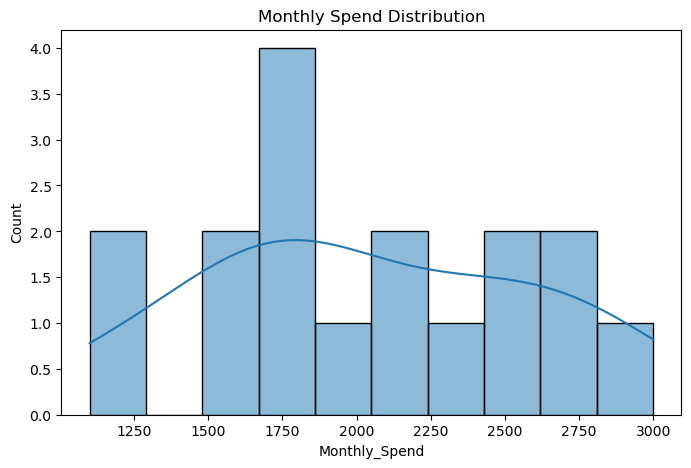

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(dataset['Monthly_Spend'], bins=10, kde=True)
plt.title("Monthly Spend Distribution")
plt.show()

# 5. Gender Count (Bar Chart)

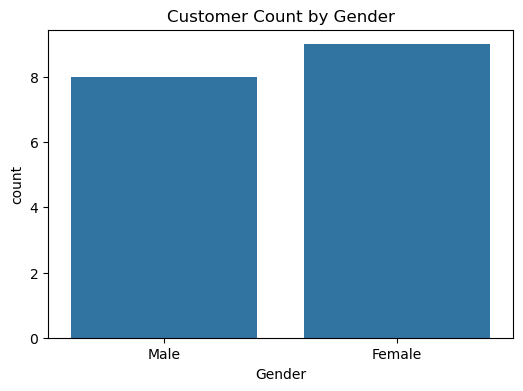

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=dataset)
plt.title("Customer Count by Gender")
plt.show()

# 6. City-wise Customer Distribution

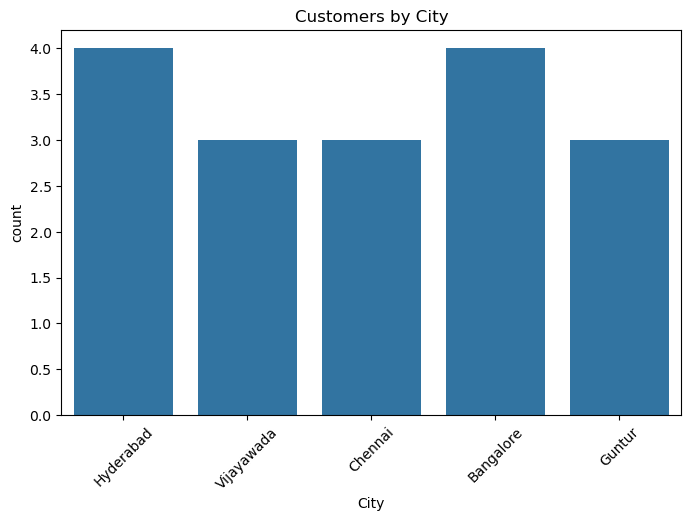

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='City', data=dataset)
plt.title("Customers by City")
plt.xticks(rotation=45)
plt.show()

# 7. Average Spending by City

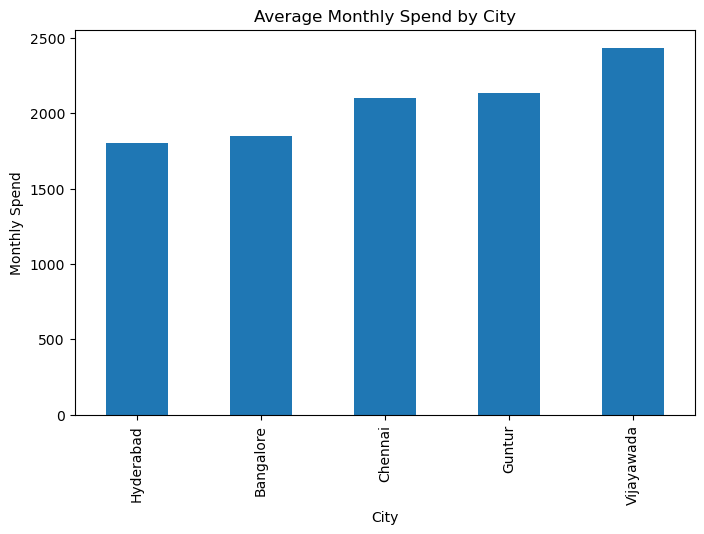

In [14]:
plt.figure(figsize=(8,5))

dataset.groupby('City')['Monthly_Spend']\
.mean()\
.sort_values()\
.plot(kind='bar')

plt.title("Average Monthly Spend by City")
plt.ylabel("Monthly Spend")
plt.show()

# 8. Box Plot for Outlier Detection

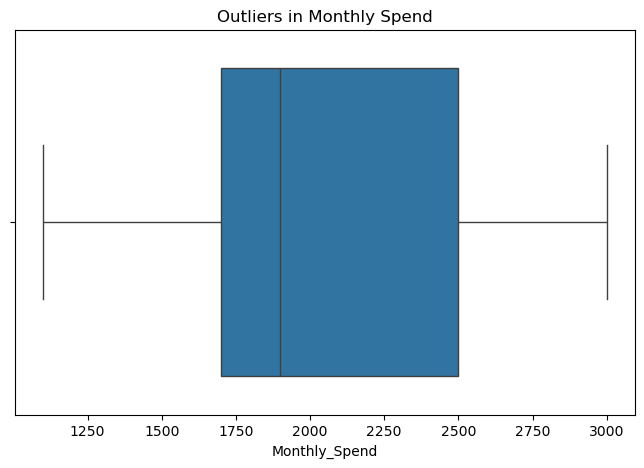

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=dataset['Monthly_Spend'])
plt.title("Outliers in Monthly Spend")
plt.show()

# 9. Orders Distribution

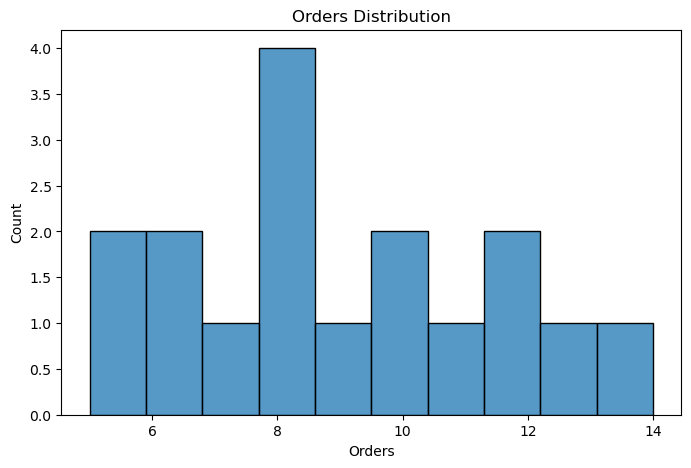

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(dataset['Orders'], bins=10)
plt.title("Orders Distribution")
plt.show()

# 10. Monthly Spend vs Orders (Scatter Plot)

- Shows relationship between spending and orders.

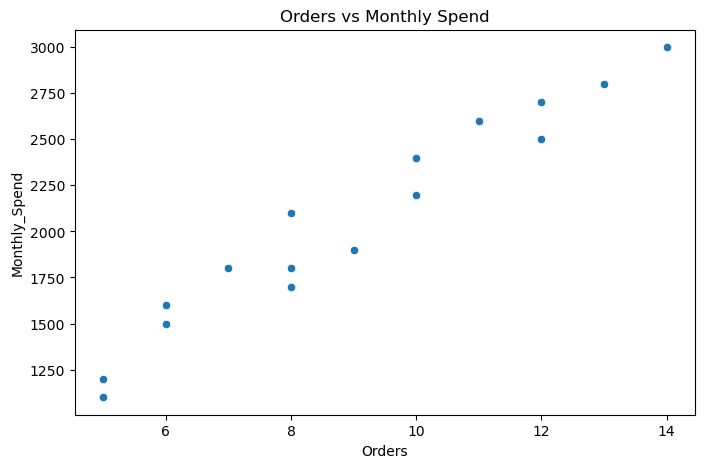

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Orders',
    y='Monthly_Spend',
    data=dataset
)

plt.title("Orders vs Monthly Spend")
plt.show()

# 11. Rating Distribution

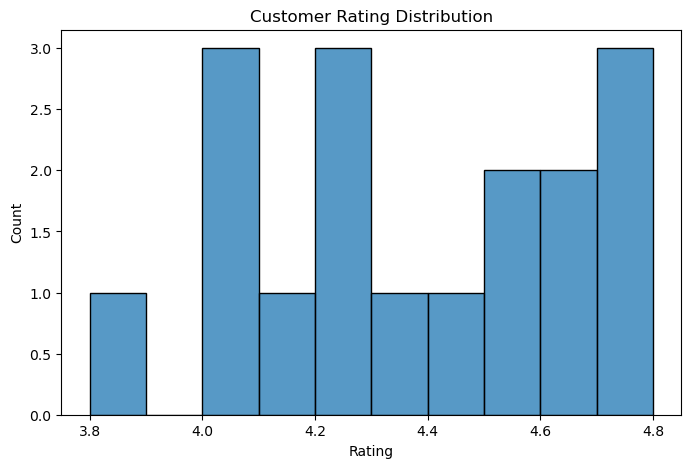

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(dataset['Rating'], bins=10)
plt.title("Customer Rating Distribution")
plt.show()

# 12. Correlation Heatmap 

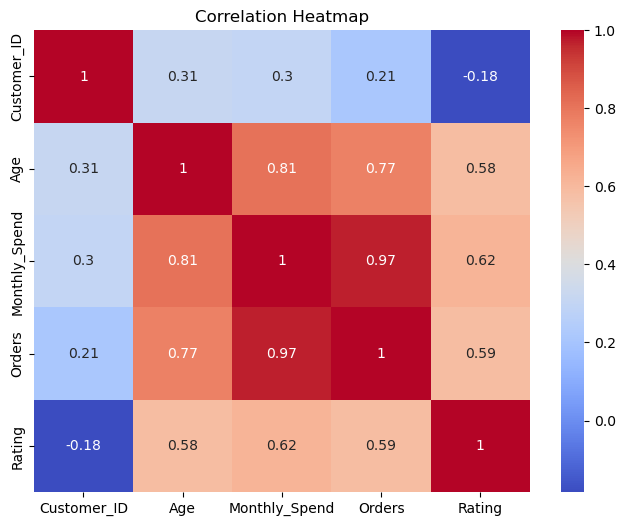

In [19]:
plt.figure(figsize=(8,6))

numeric_data = dataset.select_dtypes(include='number')

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# 13. Pair Plot

- Shows relationships between all numeric columns.

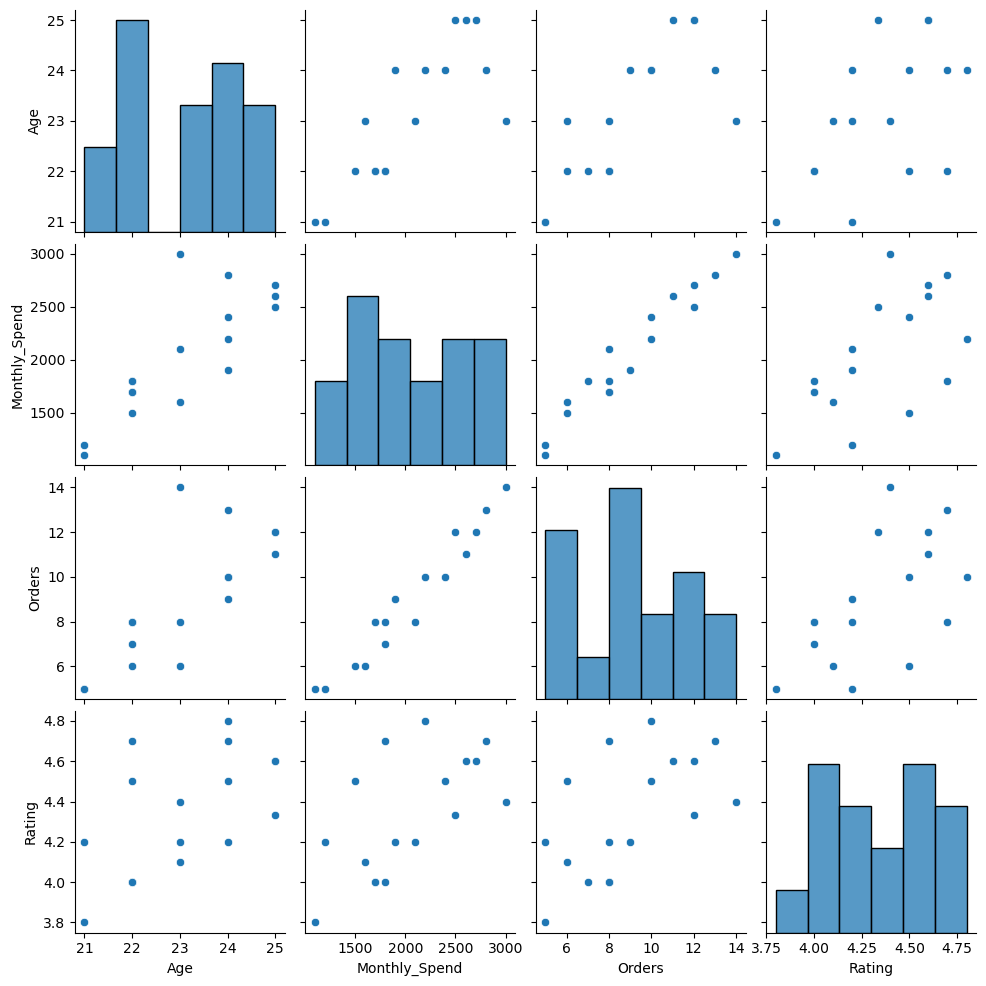

In [20]:
sns.pairplot(
    dataset[
        ['Age',
         'Monthly_Spend',
         'Orders',
         'Rating']
    ]
)

plt.show()

# 14. Pie Chart of Gender

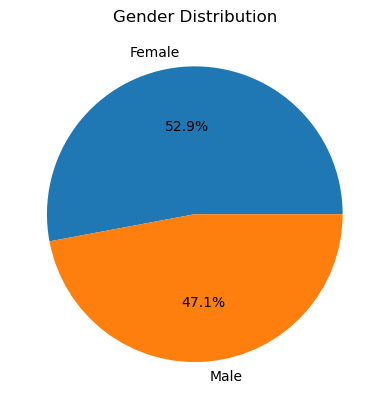

In [21]:
dataset['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

# 15. Top Spending Customers

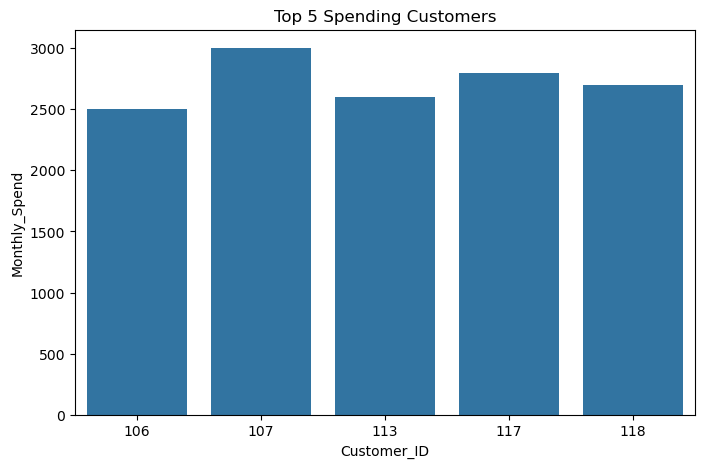

In [22]:
top_customers = dataset.nlargest(
    5,
    'Monthly_Spend'
)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Customer_ID',
    y='Monthly_Spend',
    data=top_customers
)

plt.title("Top 5 Spending Customers")
plt.show()